In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

### Load Datasets

In [2]:
disaster_df = pd.read_csv('datasets/disaster_df.csv')
indicators_df_imputed = pd.read_csv('datasets/indicators_df_imputed.csv')
demographic_df_imputed = pd.read_csv('datasets/demographic_df_imputed.csv')

### Inital Dataset Cleaning

In [3]:
# Standardize dataset feature names

# Disaster dataset
disaster_df = disaster_df.rename(columns={
    'country': 'Country',
    'year': 'Year',
})

# Indicators dataset
indicators_df_imputed = indicators_df_imputed.rename(columns={
    'country_name': 'Country',
    'year': 'Year'
})

# Demographic dataset
demographic_df_imputed = demographic_df_imputed.rename(columns={
    'Name': 'Country'
})

### Severity Prediction

In [4]:
# create copy of disaster dataset
df = disaster_df.copy()

# one-hot encode event_type
df = pd.get_dummies(df, columns=['event_type'], prefix='event')

# Target
y = df['severity']

# Features
X = df.drop(columns=['severity', 'Country', 'date'])

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [5]:
rf_base = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    max_features='sqrt',
    random_state=1,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', n_jobs=-1, random_state=1)

In [6]:
y_pred = rf_base.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Baseline RF Performance:")
print(f"MSE: {mse:.3f}")
print(f"R-squared: {r2:.3f}")

Baseline RF Performance:
MSE: 0.412
R-squared: 0.903


In [7]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "max_features": ["sqrt", "log2", None]
}

rf_tuned = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=1),
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=5,
    random_state=1,
    n_jobs=-1,
    verbose=2
)

rf_tuned.fit(X_train, y_train)

best_rf = rf_tuned.best_estimator_
print("Best Params:", rf_tuned.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'n_estimators': 500, 'max_features': 'sqrt', 'max_depth': 30}


In [8]:
y_pred_opt = best_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred_opt)
r2 = r2_score(y_test, y_pred_opt)

print("Optimized RF Performance:")
print(f"MSE: {mse:.3f}")
print(f"R-squared: {r2:.3f}")

Optimized RF Performance:
MSE: 0.403
R-squared: 0.905


In [9]:
# 5-fold CV config
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# --- Baseline RF ---
cv_mse_baseline = -cross_val_score(
    rf_base,
    X_train,
    y_train,
    scoring="neg_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

print("Baseline RF 5-Fold CV:")
print(f"MSE per fold: {cv_mse_baseline}")
print(f"Mean CV MSE: {cv_mse_baseline.mean():.3f}")
print(f"Std CV MSE: {cv_mse_baseline.std():.3f}\n")


# --- Optimized RF ---
cv_mse_opt = -cross_val_score(
    best_rf,              # from RandomizedSearchCV
    X_train,
    y_train,
    scoring="neg_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

print("Optimized RF 5-Fold CV:")
print(f"MSE per fold: {cv_mse_opt}")
print(f"Mean CV MSE: {cv_mse_opt.mean():.3f}")
print(f"Std CV MSE: {cv_mse_opt.std():.3f}")

Baseline RF 5-Fold CV:
MSE per fold: [0.423905   0.39218208 0.38965917 0.34172854 0.37134021]
Mean CV MSE: 0.384
Std CV MSE: 0.027

Optimized RF 5-Fold CV:
MSE per fold: [0.42038889 0.39025386 0.37785613 0.34076222 0.36748283]
Mean CV MSE: 0.379
Std CV MSE: 0.026


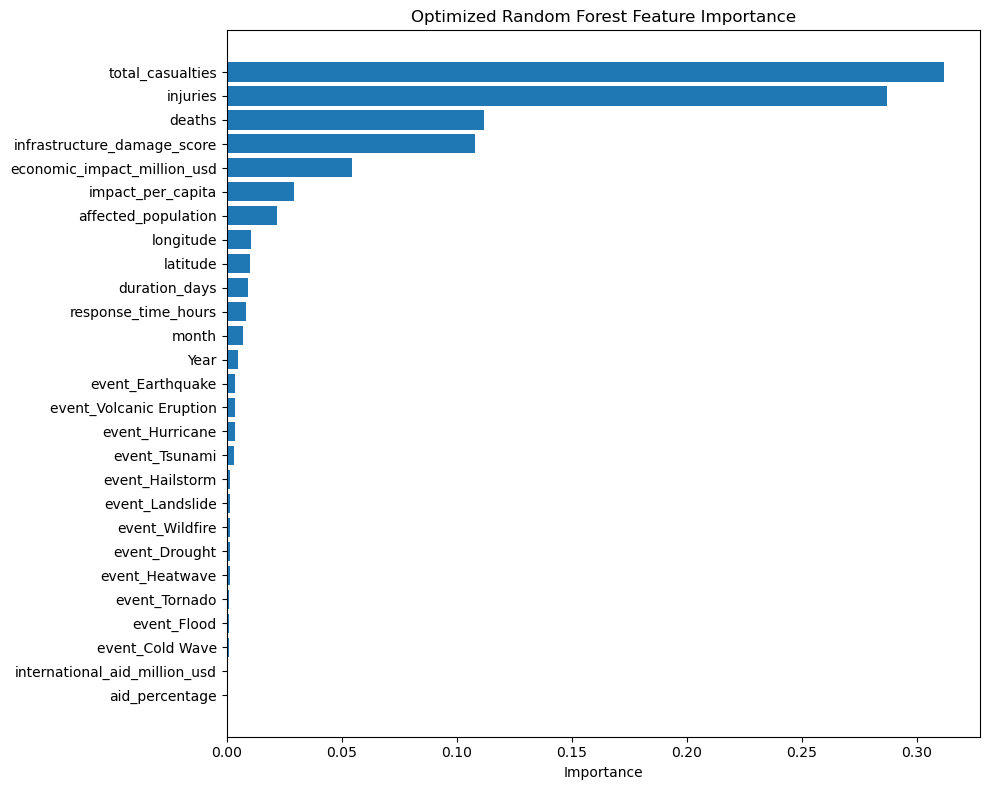

[CV] END max_depth=None, max_features=sqrt, n_estimators=400; total time=   2.4s
[CV] END ..max_depth=40, max_features=sqrt, n_estimators=200; total time=   1.2s
[CV] END ..max_depth=30, max_features=None, n_estimators=200; total time=   3.7s
[CV] END ..max_depth=20, max_features=None, n_estimators=500; total time=  10.4s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=400; total time=   2.8s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=200; total time=   1.7s
[CV] END ..max_depth=10, max_features=None, n_estimators=300; total time=   5.2s
[CV] END ..max_depth=10, max_features=log2, n_estimators=500; total time=   2.1s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=500; total time=   3.0s
[CV] END ..max_depth=30, max_features=None, n_estimators=200; total time=   3.7s
[CV] END ..max_depth=20, max_features=None, n_estimators=500; total time=  10.5s
[CV] END max_depth=None, max_features=sqrt, n_estimators=500; total time=   3.4s
[CV] END ..max_depth=30, max

In [10]:
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Optimized Random Forest Feature Importance")
plt.tight_layout()
plt.show()

### Disaster Vulnerability Clustering

In [ ]:
# Merge all 3 datasets on Country + Year
combined_df = (
    disaster_df
    .merge(indicators_df_imputed, on=['Country', 'Year'], how='left')
    .merge(demographic_df_imputed, on=['Country', 'Year'], how='left')
)

In [ ]:
# Select only numeric columns for aggregation
numeric_cols = combined_df.select_dtypes(include='number').columns

country_df = (
    combined_df
    .groupby('Country')[numeric_cols]
    .mean()
    .reset_index()
)

In [ ]:
# Remove zero variance columns
selector = VarianceThreshold()
selector.fit(country_df.select_dtypes(include='number'))
country_clean = country_df[country_df.select_dtypes(include='number').columns[selector.get_support()]]

In [ ]:
X = country_clean.values

sse = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=1)
    km.fit(X)
    sse.append(km.inertia_)

plt.plot(K, sse, marker='o')
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Elbow Method for Optimal k")
plt.show()

In [ ]:
pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('kmeans', KMeans(n_clusters=4, random_state=1))
])

pipeline.fit(country_clean)
cluster_labels = pipeline['kmeans'].labels_

country_clean['Cluster'] = cluster_labels

In [ ]:
pca2 = PCA(n_components=2)
coords = pca2.fit_transform(StandardScaler().fit_transform(country_clean.drop(columns='Cluster')))

plt.figure(figsize=(8,6))
plt.scatter(coords[:,0], coords[:,1], c=country_clean['Cluster'], s=80)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Country Disaster Vulnerability Clusters")
plt.colorbar(label='Cluster')
plt.show()